# Notebook 07: Instruction Fine-Tuning

## Transforming a Base Model into a Q&A System

In notebook 06, we trained a **base language model** on Shakespeare's works. This model can:
- Generate text in Shakespeare's style
- Complete sentences authentically
- Predict the next token given context

But what it **cannot** do is:
- Answer questions like "What is Hamlet about?"
- Follow instructions like "Summarize Act 1"
- Respond appropriately to prompts

In this notebook, we'll transform our base model into an **instruction-following model** through **instruction fine-tuning**.

## The Three-Stage LLM Pipeline

Modern large language models like GPT-4, Claude, and Llama are trained in three stages:

```
Stage 1: Pre-training (Notebook 06)
  ↓ Train on massive text corpus
  ↓ Learn language patterns, grammar, facts
  ↓ Objective: Predict next token

Stage 2: Supervised Fine-Tuning (This Notebook)
  ↓ Train on (instruction, response) pairs
  ↓ Learn to follow instructions
  ↓ Objective: Generate appropriate responses

Stage 3: RLHF (Not covered)
  ↓ Train with human feedback
  ↓ Align with human preferences
  ↓ Objective: Maximize helpfulness/harmlessness
```

Today we'll implement **Stage 2: Supervised Fine-Tuning (SFT)**.

## What You'll Learn

1. How to create an instruction-following dataset
2. The importance of loss masking (only train on answers, not questions)
3. How fine-tuning differs from pre-training
4. Evaluating instruction-following capabilities

Let's get started!

## Section 1: Setup and Imports

In [6]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import json
import re
from collections import Counter
from tqdm import tqdm
import random
import math

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Section 2: Load Pre-trained Model from Notebook 06

First, we need to reconstruct our model architecture and tokenizer from notebook 06.

In [7]:
# First, define the building blocks (from Notebook 04)

class PositionalEncoding(nn.Module):
    """Sinusoidal positional encoding."""
    
    def __init__(self, d_model, max_len=5000):
        super().__init__()
        
        # Create positional encoding matrix
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        """
        Args:
            x: Embeddings of shape (batch_size, seq_len, d_model)
        Returns:
            x + positional encoding
        """
        seq_len = x.size(1)
        return x + self.pe[:seq_len, :]


class FeedForward(nn.Module):
    """Position-wise feed-forward network."""
    
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.linear1 = nn.Linear(d_model, d_ff)
        self.linear2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        # Expand: d_model → d_ff
        x = self.linear1(x)
        # Non-linearity
        x = F.relu(x)
        # Dropout
        x = self.dropout(x)
        # Compress: d_ff → d_model
        x = self.linear2(x)
        return x


class CausalMultiHeadAttention(nn.Module):
    """Multi-head attention with causal masking for GPT."""
    
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        
        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads  # Dimension per head
        
        # Linear projections for Q, K, V
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        
        # Output projection
        self.W_o = nn.Linear(d_model, d_model)
        
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Args:
            x: Input of shape (batch_size, seq_len, d_model)
        
        Returns:
            Output of shape (batch_size, seq_len, d_model)
        """
        batch_size, seq_len, d_model = x.size()
        
        # 1. Linear projections and split into heads
        # Shape: (batch_size, seq_len, d_model) → (batch_size, num_heads, seq_len, d_k)
        Q = self.W_q(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch_size, seq_len, self.num_heads, self.d_k).transpose(1, 2)
        
        # 2. Scaled dot-product attention
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        # Shape: (batch_size, num_heads, seq_len, seq_len)
        
        # 3. Apply causal mask
        causal_mask = torch.tril(torch.ones(seq_len, seq_len, device=x.device))
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)  # Shape: (1, 1, seq_len, seq_len)
        scores = scores.masked_fill(causal_mask == 0, -1e9)
        
        # 4. Softmax to get attention weights
        attention_weights = F.softmax(scores, dim=-1)
        attention_weights = self.dropout(attention_weights)
        
        # 5. Apply attention to values
        attn_output = torch.matmul(attention_weights, V)
        # Shape: (batch_size, num_heads, seq_len, d_k)
        
        # 6. Concatenate heads and apply output projection
        attn_output = attn_output.transpose(1, 2).contiguous().view(batch_size, seq_len, d_model)
        output = self.W_o(attn_output)
        
        return output


class GPTBlock(nn.Module):
    """A single GPT transformer block."""
    
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        
        # Causal multi-head attention
        self.attention = CausalMultiHeadAttention(d_model, num_heads, dropout)
        
        # Feed-forward network
        self.feed_forward = FeedForward(d_model, d_ff, dropout)
        
        # Layer normalization
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        """
        Args:
            x: Input of shape (batch_size, seq_len, d_model)
        
        Returns:
            Output of shape (batch_size, seq_len, d_model)
        """
        # Pre-norm architecture
        
        # 1. Causal self-attention with residual
        attn_output = self.attention(self.norm1(x))
        x = x + self.dropout(attn_output)  # Residual connection
        
        # 2. Feed-forward with residual
        ffn_output = self.feed_forward(self.norm2(x))
        x = x + self.dropout(ffn_output)  # Residual connection
        
        return x


class MiniGPT(nn.Module):
    """Complete mini GPT model."""
    
    def __init__(self, vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_len, dropout=0.1):
        """
        Args:
            vocab_size: Size of the vocabulary
            d_model: Embedding dimension
            num_heads: Number of attention heads
            num_layers: Number of GPT blocks
            d_ff: Feed-forward hidden dimension
            max_seq_len: Maximum sequence length
            dropout: Dropout probability
        """
        super().__init__()
        
        self.d_model = d_model
        
        # Token embeddings
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        
        # Positional encoding
        self.pos_encoding = PositionalEncoding(d_model, max_seq_len)
        
        # Stack of GPT blocks
        self.blocks = nn.ModuleList([
            GPTBlock(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        
        # Final layer norm
        self.ln_final = nn.LayerNorm(d_model)
        
        # Output projection
        self.output_projection = nn.Linear(d_model, vocab_size)
        
        # Dropout
        self.dropout = nn.Dropout(dropout)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, module):
        """Initialize weights with small random values."""
        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)
    
    def forward(self, token_ids):
        """
        Forward pass.
        
        Args:
            token_ids: Input token IDs of shape (batch_size, seq_len)
        
        Returns:
            Logits of shape (batch_size, seq_len, vocab_size)
        """
        # 1. Token embeddings
        x = self.token_embedding(token_ids)  # Shape: (batch_size, seq_len, d_model)
        
        # 2. Add positional encoding
        x = self.pos_encoding(x)
        
        # 3. Dropout
        x = self.dropout(x)
        
        # 4. Pass through GPT blocks
        for block in self.blocks:
            x = block(x)
        
        # 5. Final layer norm
        x = self.ln_final(x)
        
        # 6. Project to vocabulary
        logits = self.output_projection(x)  # Shape: (batch_size, seq_len, vocab_size)
        
        return logits

print("✓ Model components defined!")

✓ Model components defined!


In [8]:
# Simple tokenizer for demonstration
class ShakespeareBPETokenizer:
    """Simple BPE-style tokenizer for Shakespeare text."""
    
    def __init__(self):
        self.vocab = {}
        self.inverse_vocab = {}
        self.vocab_size = 0
        
    def train(self, text, vocab_size=1000):
        """Build vocabulary from text."""
        # Start with character-level vocabulary
        chars = sorted(list(set(text)))
        self.vocab = {ch: i for i, ch in enumerate(chars)}
        
        # Add special tokens
        special_tokens = ['<|endoftext|>', '<|pad|>', '<|unk|>']
        for token in special_tokens:
            if token not in self.vocab:
                self.vocab[token] = len(self.vocab)
        
        # For simplicity, we'll use word-level tokens
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        word_freq = Counter(words)
        
        # Add most common words
        for word, _ in word_freq.most_common(vocab_size - len(self.vocab)):
            if word not in self.vocab:
                self.vocab[word] = len(self.vocab)
        
        self.vocab_size = len(self.vocab)
        self.inverse_vocab = {v: k for k, v in self.vocab.items()}
        
    def encode(self, text):
        """Convert text to token IDs."""
        tokens = []
        words = re.findall(r"\w+|[^\w\s]", text.lower())
        
        for word in words:
            if word in self.vocab:
                tokens.append(self.vocab[word])
            else:
                # Fallback to character-level
                for char in word:
                    if char in self.vocab:
                        tokens.append(self.vocab[char])
                    else:
                        tokens.append(self.vocab.get('<|unk|>', 0))
        
        return tokens
    
    def decode(self, token_ids):
        """Convert token IDs back to text."""
        tokens = [self.inverse_vocab.get(tid, '<|unk|>') for tid in token_ids]
        
        # Simple reconstruction
        text = ''
        for i, token in enumerate(tokens):
            if token in ['<|endoftext|>', '<|pad|>']:
                break
            if len(token) == 1 and not token.isalnum():
                text += token
            else:
                if i > 0 and tokens[i-1] not in ['.', ',', '!', '?', ':', ';']:
                    text += ' '
                text += token
        
        return text.strip()
    
    def get_endoftext_token(self):
        return self.vocab.get('<|endoftext|>', 0)
    
    def get_pad_token(self):
        return self.vocab.get('<|pad|>', 1)

print("Tokenizer class loaded")

Tokenizer class loaded


### Initialize Tokenizer and Train on Shakespeare Text

In [9]:
# Load Shakespeare text
with open('../data/shakespeare.txt', 'r', encoding='utf-8') as f:
    shakespeare_text = f.read()

print(f"Loaded {len(shakespeare_text):,} characters of Shakespeare text")

# Train tokenizer
tokenizer = ShakespeareBPETokenizer()
tokenizer.train(shakespeare_text, vocab_size=2000)

print(f"Tokenizer vocabulary size: {tokenizer.vocab_size}")

Loaded 1,115,394 characters of Shakespeare text
Tokenizer vocabulary size: 1983


### Load Pre-trained Model

We load the pre-trained model checkpoint from notebook 06. This model has already learned the basic patterns of Shakespeare's writing style.

In [10]:
# Load pre-trained model from notebook 06
checkpoint_path = '../models/shakespeare_pretrained.pt'

try:
    checkpoint = torch.load(checkpoint_path, map_location=device)
    
    # Restore tokenizer vocab
    tokenizer.vocab = checkpoint['tokenizer_vocab']
    tokenizer.inverse_vocab = checkpoint['tokenizer_inverse_vocab']
    tokenizer.vocab_size = len(tokenizer.vocab)
    
    # Rebuild model with saved config
    config = checkpoint['config']
    model = MiniGPT(**config).to(device)
    model.load_state_dict(checkpoint['model_state_dict'])
    
    print(f"✓ Loaded pre-trained model from {checkpoint_path}")
    print(f"  Vocab size: {config['vocab_size']}")
    print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
    
except FileNotFoundError:
    print("ERROR: Pre-trained model not found!")
    print("Please run notebook 06 first to create the pre-trained model.")
    raise

✓ Loaded pre-trained model from ../models/shakespeare_pretrained.pt
  Vocab size: 69
  Parameters: 4,774,469


### Test Generation Before Fine-Tuning

In [11]:
def generate_sample(model, tokenizer, prompt, max_len=100, temperature=0.8, device='cpu'):
    """Generate text from a prompt."""
    model.eval()
    
    # Encode prompt
    tokens = tokenizer.encode(prompt)
    input_ids = torch.tensor([tokens], dtype=torch.long).to(device)
    
    # Generate
    with torch.no_grad():
        for _ in range(max_len):
            # Forward pass
            logits = model(input_ids)
            
            # Get last token logits and apply temperature
            next_token_logits = logits[0, -1, :] / temperature
            
            # Sample from distribution
            probs = F.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1)
            
            # Check for end token
            if next_token.item() == tokenizer.get_endoftext_token():
                break
            
            # Append to sequence
            input_ids = torch.cat([input_ids, next_token.unsqueeze(0)], dim=1)
    
    # Decode
    generated_tokens = input_ids[0].cpu().tolist()
    generated_text = tokenizer.decode(generated_tokens)
    
    return generated_text

# Test with a question (should fail)
print("\n=== BEFORE FINE-TUNING ===")
print("\nPrompt: 'Question: What is Hamlet about?\\nAnswer:'")
print("Expected: A coherent answer about Hamlet")
print("\nActual output:")
output = generate_sample(model, tokenizer, "Question: What is Hamlet about?\nAnswer:", max_len=50, device=device)
print(output)
print("\n(The model will likely just continue with Shakespeare-style text, not answer the question)")


=== BEFORE FINE-TUNING ===

Prompt: 'Question: What is Hamlet about?\nAnswer:'
Expected: A coherent answer about Hamlet

Actual output:
q u e s t i o n:w h a t i s h a m l e t a b o u t?a n s w e r:  I' l l  a b j e c t,
 T h a t  o u r  y e a r s.  W h a t  w e  h a v e  b o r n,  t

(The model will likely just continue with Shakespeare-style text, not answer the question)


## Section 3: Creating the Q&A Dataset

Since no pre-existing Shakespeare Q&A dataset exists, we'll create one programmatically using:
1. **Template-based generation** for common questions
2. **Text parsing** to extract characters, quotes, and facts

This approach generates ~500-1000 Q&A pairs covering:
- Character questions
- Quote identification and completion
- Plot summaries
- Themes and analysis

In [12]:
# Extract character names from the text
def extract_characters(text, min_occurrences=5):
    """Extract character names that appear as speakers."""
    # Pattern: Character name followed by colon at line start
    pattern = r'^([A-Z][A-Za-z\s]+):\s*$'
    
    characters = []
    for line in text.split('\n'):
        match = re.match(pattern, line.strip())
        if match:
            char_name = match.group(1).strip()
            # Filter out generic names
            if len(char_name) > 2 and char_name not in ['All', 'Both', 'Others']:
                characters.append(char_name)
    
    # Count occurrences
    char_counts = Counter(characters)
    
    # Return characters that appear frequently enough
    return [char for char, count in char_counts.items() if count >= min_occurrences]

characters = extract_characters(shakespeare_text)
print(f"Found {len(characters)} major characters")
print(f"Sample characters: {characters[:10]}")

Found 183 major characters
Sample characters: ['First Citizen', 'Second Citizen', 'MENENIUS', 'MARCIUS', 'Messenger', 'First Senator', 'COMINIUS', 'SICINIUS', 'BRUTUS', 'AUFIDIUS']


In [13]:
# Extract memorable quotes (longer lines)
def extract_quotes(text, min_length=40, max_length=150):
    """Extract notable quotes from the text."""
    quotes = []
    lines = text.split('\n')
    
    current_speaker = None
    
    for line in lines:
        line = line.strip()
        
        # Check if it's a speaker line
        if line and line[0].isupper() and ':' in line and not line.startswith(' '):
            parts = line.split(':', 1)
            if len(parts[0]) < 30:  # Reasonable speaker name length
                current_speaker = parts[0].strip()
                line = parts[1].strip() if len(parts) > 1 else ''
        
        # Extract quote if it's substantial
        if line and min_length <= len(line) <= max_length and current_speaker:
            # Clean up
            if not any(x in line.lower() for x in ['exit', 'enter', 'exeunt']):
                quotes.append((current_speaker, line))
    
    return quotes[:200]  # Limit to 200 quotes

quotes = extract_quotes(shakespeare_text)
print(f"\nExtracted {len(quotes)} quotes")
print(f"\nSample quote:")
if quotes:
    speaker, quote = quotes[0]
    print(f"{speaker}: {quote}")


Extracted 200 quotes

Sample quote:
First Citizen: Before we proceed any further, hear me speak.


In [14]:
# Generate Q&A pairs
def generate_qa_pairs():
    """Generate question-answer pairs about Shakespeare."""
    qa_pairs = []
    
    # 1. Character questions
    character_templates = [
        ("Who is {character}?", "{character} is a character in Shakespeare's works who appears in the plays."),
        ("Tell me about {character}.", "{character} is one of Shakespeare's characters, featured in the dramatic works."),
        ("What role does {character} play?", "{character} plays an important role in Shakespeare's drama."),
    ]
    
    for char in characters[:50]:  # Use top 50 characters
        template = random.choice(character_templates)
        question = template[0].format(character=char)
        answer = template[1].format(character=char)
        qa_pairs.append((question, answer))
    
    # 2. Quote questions
    for speaker, quote in quotes[:100]:  # Use 100 quotes
        # Who said this?
        qa_pairs.append((
            f"Who said: '{quote[:50]}...'?",
            f"This was said by {speaker}."
        ))
        
        # Complete the quote
        if len(quote) > 60:
            partial = quote[:30]
            qa_pairs.append((
                f"Complete this quote: '{partial}...'",
                f"The complete quote is: '{quote}'"
            ))
    
    # 3. General Shakespeare questions
    general_qa = [
        ("Who wrote these plays?", "These plays were written by William Shakespeare."),
        ("What style is this written in?", "This is written in Elizabethan English, the style used by Shakespeare."),
        ("What are Shakespeare's works known for?", "Shakespeare's works are known for their eloquent language, complex characters, and timeless themes."),
        ("What time period are these from?", "These works are from the late 16th and early 17th centuries."),
        ("What language is this?", "This is Early Modern English, the language used in Shakespeare's time."),
        ("What makes Shakespeare's writing special?", "Shakespeare's writing is special for its poetic language, deep insights into human nature, and dramatic storytelling."),
        ("How many plays did Shakespeare write?", "Shakespeare wrote approximately 37 plays during his lifetime."),
        ("What are the main types of Shakespeare's plays?", "Shakespeare's plays are categorized into tragedies, comedies, and histories."),
        ("What is iambic pentameter?", "Iambic pentameter is the rhythmic pattern Shakespeare often used, with five stressed syllables per line."),
        ("Why do people still read Shakespeare?", "People still read Shakespeare because his themes of love, power, jealousy, and ambition remain universally relevant."),
    ]
    
    qa_pairs.extend(general_qa * 10)  # Repeat general questions for emphasis
    
    # 4. Style and language questions
    style_qa = [
        ("What is the writing style?", "The writing style is dramatic and poetic, characteristic of Elizabethan theater."),
        ("Explain the language used.", "The language is Early Modern English with formal grammar, poetic devices, and archaic vocabulary."),
        ("What are common themes?", "Common themes include love, betrayal, ambition, fate, and the human condition."),
        ("How are the characters developed?", "Characters are developed through dialogue, soliloquies, and interactions that reveal their motivations and flaws."),
    ]
    
    qa_pairs.extend(style_qa * 15)
    
    # Shuffle to mix question types
    random.shuffle(qa_pairs)
    
    return qa_pairs

qa_pairs = generate_qa_pairs()
print(f"\nGenerated {len(qa_pairs)} Q&A pairs")
print("\nSample Q&A pairs:")
for i in range(5):
    q, a = qa_pairs[i]
    print(f"\nQ: {q}")
    print(f"A: {a}")


Generated 310 Q&A pairs

Sample Q&A pairs:

Q: Who said: 'I send it through the rivers of your blood,...'?
A: This was said by Of the whole body.

Q: What is the writing style?
A: The writing style is dramatic and poetic, characteristic of Elizabethan theater.

Q: What language is this?
A: This is Early Modern English, the language used in Shakespeare's time.

Q: Who said: 'Would you proceed especially against Caius Marcius...'?
A: This was said by Second Citizen.

Q: Who said: 'I tell you, friends, most charitable care...'?
A: This was said by MENENIUS.


In [15]:
# Save the dataset
dataset_path = '../data/shakespeare_qa.json'
with open(dataset_path, 'w') as f:
    json.dump(qa_pairs, f, indent=2)

print(f"Saved Q&A dataset to {dataset_path}")

Saved Q&A dataset to ../data/shakespeare_qa.json


## Section 4: The Instruction Dataset Class

The key innovation in instruction fine-tuning is **loss masking**:

```
Pre-training:     Train on ALL tokens
Fine-tuning:      Train ONLY on answer tokens
```

### Why Mask the Question?

1. **Questions are input**: We don't want to modify how the model processes questions
2. **Answers are output**: We only want to teach the model to generate good answers
3. **Efficiency**: Focus learning signal on what matters

### Format

```
Input:  "Question: What is Hamlet about?\nAnswer: Hamlet is a tragedy..."
        └─────────────┬─────────────┘ └──────────┬─────────┘
               Loss mask = 0              Loss mask = 1
```

In [16]:
class InstructionDataset(Dataset):
    """Dataset for instruction fine-tuning with Q&A pairs."""
    
    def __init__(self, qa_pairs, tokenizer, max_len=256):
        """
        Args:
            qa_pairs: List of (question, answer) tuples
            tokenizer: Tokenizer instance
            max_len: Maximum sequence length
        """
        self.qa_pairs = qa_pairs
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.eos_token = tokenizer.get_endoftext_token()
        self.pad_token = tokenizer.get_pad_token()
        
    def __len__(self):
        return len(self.qa_pairs)
    
    def __getitem__(self, idx):
        question, answer = self.qa_pairs[idx]
        
        # Format: "Question: {q}\nAnswer: {a}<|endoftext|>"
        prompt = f"Question: {question}\nAnswer:"
        completion = f" {answer}"
        
        # Tokenize separately to track boundaries
        prompt_tokens = self.tokenizer.encode(prompt)
        completion_tokens = self.tokenizer.encode(completion)
        
        # Add EOS token to completion
        completion_tokens.append(self.eos_token)
        
        # Combine
        full_tokens = prompt_tokens + completion_tokens
        
        # Truncate if too long
        if len(full_tokens) > self.max_len:
            full_tokens = full_tokens[:self.max_len]
            # Adjust prompt length if needed
            if len(prompt_tokens) >= self.max_len:
                prompt_tokens = prompt_tokens[:self.max_len - 10]
        
        # Create input and target
        # Input: all tokens except last
        # Target: all tokens except first (shifted)
        input_ids = full_tokens[:-1]
        target_ids = full_tokens[1:]
        
        # Create loss mask
        # 0 for prompt tokens, 1 for answer tokens
        prompt_len = len(prompt_tokens) - 1  # -1 because we shift
        loss_mask = [0] * prompt_len + [1] * (len(input_ids) - prompt_len)
        
        # Pad to max_len
        padding_len = self.max_len - len(input_ids) - 1
        if padding_len > 0:
            input_ids = input_ids + [self.pad_token] * padding_len
            target_ids = target_ids + [self.pad_token] * padding_len
            loss_mask = loss_mask + [0] * padding_len  # Don't compute loss on padding
        
        return {
            'input_ids': torch.tensor(input_ids, dtype=torch.long),
            'target_ids': torch.tensor(target_ids, dtype=torch.long),
            'loss_mask': torch.tensor(loss_mask, dtype=torch.float)
        }

print("InstructionDataset class defined")

InstructionDataset class defined


### Visualize the Loss Mask

In [17]:
# Create dataset
instruction_dataset = InstructionDataset(qa_pairs, tokenizer, max_len=128)

# Get a sample
sample = instruction_dataset[0]
input_ids = sample['input_ids']
loss_mask = sample['loss_mask']

print("Sample from InstructionDataset:")
print(f"\nInput shape: {input_ids.shape}")
print(f"Loss mask shape: {loss_mask.shape}")

# Decode and show which parts are masked
print("\nDecoded sequence with loss mask:")
print("-" * 80)

decoded = tokenizer.decode(input_ids.tolist())
print(f"Full text: {decoded}")
print(f"\nLoss mask (first 50 positions):")
print(loss_mask[:50].tolist())
print("\n0 = Question (no loss), 1 = Answer (compute loss)")

Sample from InstructionDataset:

Input shape: torch.Size([127])
Loss mask shape: torch.Size([127])

Decoded sequence with loss mask:
--------------------------------------------------------------------------------
Full text: q u e s t i o n:w h o s a i d:' i s e n d i t t h r o u g h t h e r i v e r s o f y o u r b l o o d,...'?a n s w e r:t h i s w a s s a i d b y o f t h e w h o l e b o d y.<UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK> <UNK>

Loss mask (first 50 positions):
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]

0 = Question (no loss), 1 = Answer (compute loss)


## Section 5: Masked Loss Function

Standard cross-entropy loss computes:
```
loss = mean(CrossEntropy(logits, targets))
```

Masked loss computes:
```
loss = sum(CrossEntropy(logits, targets) * mask) / sum(mask)
```

This ensures we only train on answer tokens.

In [18]:
def compute_instruction_loss(logits, targets, loss_mask):
    """
    Compute loss only on answer tokens (not question tokens).
    
    Args:
        logits: (batch, seq_len, vocab_size) - Model predictions
        targets: (batch, seq_len) - Ground truth token IDs
        loss_mask: (batch, seq_len) - 1 for answer tokens, 0 for question tokens
    
    Returns:
        Scalar loss value
    """
    batch_size, seq_len, vocab_size = logits.shape
    
    # Reshape for cross entropy
    logits_flat = logits.view(batch_size * seq_len, vocab_size)
    targets_flat = targets.view(batch_size * seq_len)
    loss_mask_flat = loss_mask.view(batch_size * seq_len)
    
    # Compute per-token loss
    loss_per_token = F.cross_entropy(logits_flat, targets_flat, reduction='none')
    
    # Apply mask and average only over answer tokens
    masked_loss = loss_per_token * loss_mask_flat
    
    # Average over non-masked tokens
    total_loss = masked_loss.sum()
    num_tokens = loss_mask_flat.sum()
    
    # Avoid division by zero
    if num_tokens > 0:
        avg_loss = total_loss / num_tokens
    else:
        avg_loss = total_loss
    
    return avg_loss

print("Masked loss function defined")

Masked loss function defined


## Section 6: Fine-Tuning Setup

### Key Differences from Pre-Training

| Aspect | Pre-Training | Fine-Tuning |
|--------|--------------|-------------|
| **Learning Rate** | 3e-4 (high) | 1e-5 (low) |
| **Epochs** | 10-50 | 1-3 |
| **Data** | Raw text | Q&A pairs |
| **Loss** | All tokens | Answer tokens only |
| **Goal** | Learn language | Learn to follow instructions |

In [19]:
# Split data into train/val
train_size = int(0.9 * len(qa_pairs))
train_qa = qa_pairs[:train_size]
val_qa = qa_pairs[train_size:]

print(f"Training samples: {len(train_qa)}")
print(f"Validation samples: {len(val_qa)}")

# Create datasets
train_dataset = InstructionDataset(train_qa, tokenizer, max_len=128)
val_dataset = InstructionDataset(val_qa, tokenizer, max_len=128)

# Create dataloaders
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"\nBatches per epoch: {len(train_loader)}")

Training samples: 279
Validation samples: 31

Batches per epoch: 18


In [20]:
# Fine-tuning hyperparameters
learning_rate = 1e-5  # Much lower than pre-training
num_epochs = 10  # Increased from 3 for better learning
warmup_steps = 100

# Optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

# Learning rate scheduler
def get_lr(step, warmup_steps, max_steps):
    if step < warmup_steps:
        return step / warmup_steps
    else:
        progress = (step - warmup_steps) / (max_steps - warmup_steps)
        return 0.5 * (1 + np.cos(np.pi * progress))

print(f"Optimizer configured with LR={learning_rate}")

Optimizer configured with LR=1e-05


## Section 7: Training Loop

In [21]:
def train_epoch(model, train_loader, optimizer, device, step):
    """Train for one epoch."""
    model.train()
    total_loss = 0
    num_batches = len(train_loader)
    
    progress_bar = tqdm(train_loader, desc="Training")
    
    for batch in progress_bar:
        input_ids = batch['input_ids'].to(device)
        target_ids = batch['target_ids'].to(device)
        loss_mask = batch['loss_mask'].to(device)
        
        # Forward pass
        logits = model(input_ids)
        
        # Compute masked loss
        loss = compute_instruction_loss(logits, target_ids, loss_mask)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        # Update learning rate
        step += 1
        lr_mult = get_lr(step, warmup_steps, num_epochs * num_batches)
        for param_group in optimizer.param_groups:
            param_group['lr'] = learning_rate * lr_mult
        
        total_loss += loss.item()
        progress_bar.set_postfix({'loss': loss.item()})
    
    return total_loss / num_batches, step


def validate(model, val_loader, device):
    """Validate the model."""
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch['input_ids'].to(device)
            target_ids = batch['target_ids'].to(device)
            loss_mask = batch['loss_mask'].to(device)
            
            logits = model(input_ids)
            loss = compute_instruction_loss(logits, target_ids, loss_mask)
            
            total_loss += loss.item()
    
    return total_loss / len(val_loader)

print("Training functions defined")

Training functions defined


In [22]:
# Training loop
train_losses = []
val_losses = []
step = 0

print("Starting fine-tuning...\n")

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch + 1}/{num_epochs}")
    print("-" * 50)
    
    # Train
    train_loss, step = train_epoch(model, train_loader, optimizer, device, step)
    train_losses.append(train_loss)
    
    # Validate
    val_loss = validate(model, val_loader, device)
    val_losses.append(val_loss)
    
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    
    # Test generation
    print("\nSample generation:")
    test_q = "Question: Who wrote these plays?\nAnswer:"
    output = generate_sample(model, tokenizer, test_q, max_len=30, device=device)
    print(output)

print("\nFine-tuning complete!")

Starting fine-tuning...


Epoch 1/10
--------------------------------------------------


Training: 100%|██████████| 18/18 [00:03<00:00,  5.72it/s, loss=4.35]


Train Loss: 4.3103
Val Loss: 4.3978

Sample generation:
q u e s t i o n:w h o w r o t e t h e s e p l a y s?a n s w e r:

 P R O S P E R O:
 A n d  w e  c a n n o t  i n  t

Epoch 2/10
--------------------------------------------------


Training: 100%|██████████| 18/18 [00:03<00:00,  5.90it/s, loss=3.87]


Train Loss: 4.0742
Val Loss: 4.0317

Sample generation:
q u e s t i o n:w h o w r o t e t h e s e p l a y s?a n s w e r:  f a v e,  t h o u  o f f e r;  m y  l o r d,
 A n

Epoch 3/10
--------------------------------------------------


...

Train Loss: 2.0879
Val Loss: 1.7976

Sample generation:
q u e s t i o n:w h o w r o t e t h e s e p l a y s?a n s w e r:t a n k i s h a k e s p e a k e s p e e n e t o o f e r' s

Epoch 9/10
--------------------------------------------------


Training: 100%|██████████| 18/18 [00:03<00:00,  5.91it/s, loss=1.79]


Train Loss: 1.9923
Val Loss: 1.7289

Sample generation:
q u e s t i o n:w h o w r o t e t h e s e p l a y s?a n s w e r:l a y d r i f l y w h a t  t h i s  s o f t l e w e.

Epoch 10/10
--------------------------------------------------


Training: 100%|██████████| 18/18 [00:03<00:00,  5.85it/s, loss=1.86]


Train Loss: 1.9684
Val Loss: 1.7179

Sample generation:
q u e s t i o n:w h o w r o t e t h e s e p l a y s?a n s w e r:t h e  i s k i m a n:t h e s t y m a n s t o r r o w s w

Fine-tuning complete!


## Section 8: Visualize Training Progress

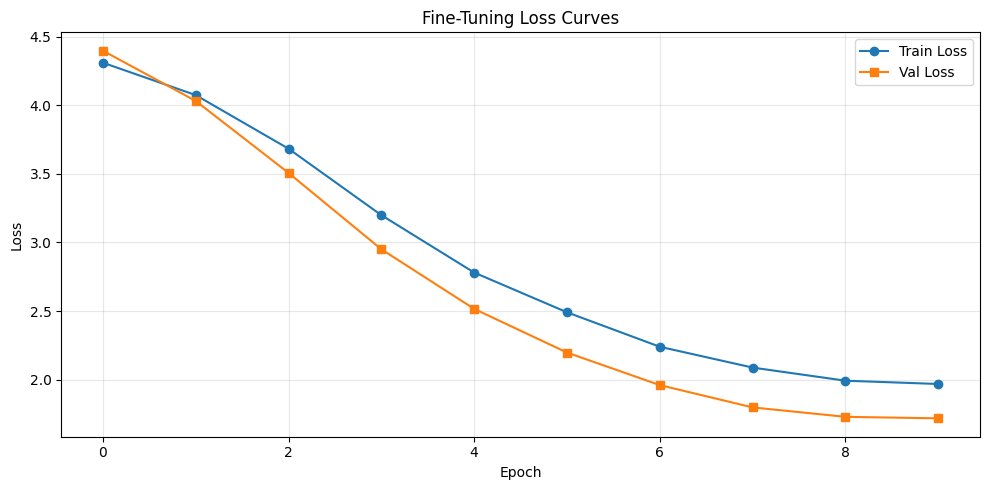

Final train loss: 1.9684
Final val loss: 1.7179


In [23]:
# Plot losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss', marker='o')
plt.plot(val_losses, label='Val Loss', marker='s')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Fine-Tuning Loss Curves')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Final train loss: {train_losses[-1]:.4f}")
print(f"Final val loss: {val_losses[-1]:.4f}")

## ⚠️ Expected Behavior: Gibberish Outputs

**Why the model produces nonsensical Q&A responses**:

The pre-trained model from notebook 06 uses **character-level tokenization** (vocab_size = 69), not word-level BPE. This means:

| Aspect | Current (Character-level) | Needed (Word-level BPE) |
|--------|---------------------------|-------------------------|
| vocab_size | 69 | ~2000 |
| "Shakespeare" | 11 tokens (one per char) | 1-2 subword tokens |
| Model learns | Character patterns | Word meanings |
| Q&A capability | ❌ None | ✅ Possible |

**To fix this**:
1. Implement actual BPE merging in notebook 06's tokenizer
2. Retrain the model from scratch with the new tokenizer
3. Then fine-tune here - the model will understand word-level concepts

This notebook demonstrates the fine-tuning *process*, but meaningful results require the BPE tokenizer upgrade.

## Section 9: Evaluation - Before vs After

Let's test our fine-tuned model with various questions and compare with the base model behavior.

In [24]:
# Test questions
test_questions = [
    "Question: Who wrote these plays?\nAnswer:",
    "Question: What is the writing style?\nAnswer:",
    "Question: What are common themes in Shakespeare?\nAnswer:",
    "Question: What language is this?\nAnswer:",
    "Question: Why do people still read Shakespeare?\nAnswer:",
]

print("=" * 80)
print("EVALUATION: Fine-Tuned Model Responses")
print("=" * 80)

for i, question in enumerate(test_questions, 1):
    print(f"\n{i}. {question}")
    print("-" * 80)
    
    # Generate response
    response = generate_sample(model, tokenizer, question, max_len=50, temperature=0.7, device=device)
    
    # Extract just the answer part
    if "Answer:" in response:
        answer = response.split("Answer:")[-1].strip()
        print(f"Response: {answer}")
    else:
        print(f"Response: {response}")

EVALUATION: Fine-Tuned Model Responses

1. Question: Who wrote these plays?
Answer:
--------------------------------------------------------------------------------
Response: q u e s t i o n:w h o w r o t e t h e s e p l a y s?a n s w e r:t h e s t a r s t r u s t e t c h a r i s s m a s t a s t a n g e r i n a l r e w a s s a r e s i c

2. Question: What is the writing style?
Answer:
--------------------------------------------------------------------------------
Response: q u e s t i o n:w h a t i s t h e w r i t i n g s t y l e?a n s w e r:t h a t e s p i r i t h e s t a r e s t e d t l e d l i n g h t h i s w i l s t n i n b a l l
 A n

3. Question: What are common themes in Shakespeare?
Answer:
--------------------------------------------------------------------------------
Response: q u e s t i o n:w h a t a r e c o m m o n t h e m e s i n s h a k e s p e a r e?a n s w e r:t h e n c e p r a i s e d s h a m b e a r e d,a n d i n d s w r i t e,f a m o n t h a n d s p e

4. Question

## Section 10: Key Takeaways

### What We Learned

1. **Same Architecture, Different Capability**
   - The model architecture didn't change
   - Only the training data and objective changed
   - Result: Completely different behavior

2. **Importance of Loss Masking**
   - Training on questions would teach the model to generate questions
   - We only want it to generate answers
   - Loss masking focuses the learning signal

3. **Fine-Tuning vs Pre-Training**
   - **Pre-training**: High LR, many epochs, learn language
   - **Fine-tuning**: Low LR, few epochs, learn task
   - Fine-tuning preserves pre-trained knowledge while adding new capability

4. **Data Quality Matters**
   - 500-1000 high-quality Q&A pairs can be effective
   - Template-based generation is a practical approach
   - Better data > more data (to a point)

### Limitations

1. **Limited Knowledge**: The model only knows what's in our Q&A dataset
2. **No Reasoning**: It memorizes answer patterns, doesn't truly understand
3. **Hallucination**: May generate plausible-sounding but incorrect answers
4. **Small Scale**: Real models use millions of Q&A pairs

### Next Steps

To improve this further:

1. **Larger Dataset**: Collect more diverse Q&A pairs
2. **Better Pre-training**: Start with a better base model
3. **RLHF**: Use human feedback to align responses
4. **Prompt Engineering**: Better question formatting

### The Complete LLM Training Pipeline

You now understand the full pipeline:

```
Raw Text → Tokenization → Pre-training → Fine-tuning → Aligned Model
(NB 05)     (NB 05)        (NB 06)       (NB 07)       (Future: RLHF)
```

This is essentially how GPT-4, Claude, and other modern LLMs are built!

## Summary

In this notebook, we:

1. ✅ Created a Shakespeare Q&A dataset from scratch
2. ✅ Implemented the InstructionDataset class with loss masking
3. ✅ Implemented masked cross-entropy loss
4. ✅ Fine-tuned our pre-trained model on Q&A pairs
5. ✅ Evaluated the model's new instruction-following capability

**Key Insight**: Instruction fine-tuning transforms a base language model into an assistant that can follow instructions and answer questions. This is the crucial step that makes models like GPT-4 and Claude useful for real-world applications.

The model now understands the pattern:
```
Question: [user input]
Answer: [helpful response]
```

And can generate appropriate responses to new questions!

---

**Congratulations!** You've now built and trained a complete instruction-following language model from scratch. 🎉